## 验证铰接模型
### 采用Yoon等人的模型
### 该验证铰接模型的方案为：
### 1、在有限元中建模子模块，导出结构刚度矩阵与质量矩阵，在该程序中进行拼接。
### 2、拼接后，识别铰接点的位置编号，通过编号输入刚度矩阵来限制铰接，得到包含铰接刚度的结构刚度矩阵。
### 3、采用Reduced-order model进行处理结构刚度矩阵到与水动力同一维度，建立控制方程。

### 结论：在单铰接的情况结果相对较好，在多铰接情况下始终与Yoon等人论文中的结果存在差异
### 工作开展时间为：2024年8月

In [1]:
#import packages
import time
import numpy as np
import capytaine as cpt
import scipy
from capytaine.io.mesh_writers import write_STL
import matplotlib.pyplot as plt
from scipy.linalg import block_diag
from scipy.linalg import eigh
import vtk
import logging
import xarray as xr
from capytaine.io.xarray import merge_complex_values
from capytaine.post_pro import rao
logging.basicConfig(level=logging.INFO, format='%(levelname)-8s: %(message)s')
# user defined functions
import DM_ShowNodes as DMshow
import DM_Reading as dm_r
import DM_Assemble as DM_A
import SEREP as SEREP
import DM_Method as DM_M
import pandas as pd

### 为了方便调整参数形成的完整程序

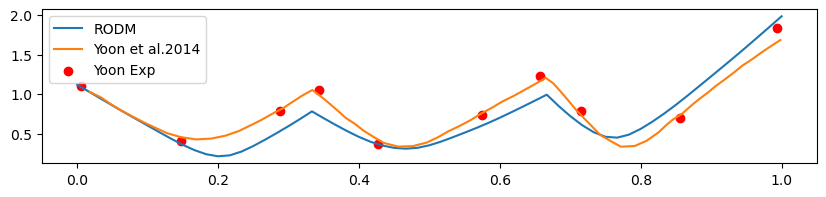

In [33]:
def input_parameters():
    # 输入文件路径
    file_m = r'E:\phd\Code\DM-FEM2D\StructureData\Yoon_hinge\Job_hinge_study_100_60_YoonModel-1_MASS1_rho282.mtx'
    file_k = r'E:\phd\Code\DM-FEM2D\StructureData\Yoon_hinge\Job_hinge_study_100_60_YoonModel-1_STIF1_rho282.mtx'
    hydro_file = r'E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoon_hinge\DM10_direction180_slender180_rho1025.nc'  # 水动力数据文件路径

    # 获取刚度矩阵和质量矩阵
    m = dm_r.get_stiffness_matrix(file_m)
    k = dm_r.get_stiffness_matrix(file_k)

    # 设置结构的数量
    n = 3  # 例如，3个结构

    # 使用相同的函数生成刚度矩阵和质量矩阵的块对角矩阵
    fem_k = create_block_matrix(k, n)
    fem_m = create_block_matrix(m, n)

    # 铰链刚度
    k_hinge = 1E15

    # 定义所有铰接节点对的列表
    hinges = [
        ([21, 42, 63, 84, 105, 126, 147, 168, 189, 210, 231, 252, 273],
         [274, 295, 316, 337, 358, 379, 400, 421, 442, 463, 484, 505, 526]),
        ([294, 315, 336, 357, 378, 399, 420, 441, 462, 483, 504, 525, 546],
         [547, 568, 589, 610, 631, 652, 673, 694, 715, 736, 757, 778, 799])
    ]

    # 主要控制节点
    master_nodes = sorted([144, 138, 132, 146+273, 140+273,134+273,128+273, 142+273*2,136+273*2,130+273*2])
    # sorted([130,136,142,128+273,134+273,140+273,146+273,132+273+273,138+273+273,144+273+273])  # 主节点
    # sorted([144, 138, 132, 146+273, 140+273,134+273,128+273, 142+273*2,136+273*2,130+273*2])
    # master_nodes = sorted([132,142,405,415,678,688])
    # master_nodes = DM_A.calculate_node_positions(424,6,10)

    # 总节点数
    num_nodes = 793 + 13 + 13
    
    # 控制选项: 使用SEREP还是Static Condensation
    use_serep = False  # True表示使用SEREP，False表示使用Static Condensation

    return fem_k, fem_m, k_hinge, hinges, master_nodes, num_nodes, hydro_file, use_serep


# 计算程序
# 将单个结构的刚度矩阵拼接为大的矩阵
def create_block_matrix(matrix, n):
    """
    创建一个 n 个结构的块对角矩阵。
    matrix 是单个结构的刚度或质量矩阵，n 是结构的数量。
    """
    zero_matrix = np.zeros_like(matrix)
    blocks = []

    for i in range(n):
        row_blocks = [zero_matrix] * n
        row_blocks[i] = matrix
        blocks.append(row_blocks)

    big_matrix = np.block(blocks)
    return big_matrix

def apply_hinge_joints(fem_kiffness, k_hinge, hinges):
    """
    将铰链关节刚度矩阵应用到全局刚度矩阵中，适用于多个模块之间的铰接。

    参数:
    fem_kiffness (numpy.ndarray): 全局刚度矩阵。
    k_hinge (float): 铰链关节的刚度。
    hinges (list of tuple): 每个铰接节点对的列表，每个元组包含两个节点编号列表。

    返回:
    numpy.ndarray: 更新后的全局刚度矩阵。
    """
    # 定义铰链关节的刚度矩阵
    KC = np.diag([k_hinge, k_hinge, k_hinge, k_hinge, 1, k_hinge])
    negative_KC = -KC

    # 处理所有铰接
    for nodes_k1, nodes_k2 in hinges:
        for node1, node2 in zip(nodes_k1, nodes_k2):
            # 计算在大矩阵中的索引位置
            index1 = (node1 - 1) * 6  # K_1 节点自由度起始位置
            index2 = (node2 - 1) * 6  # K_2 节点自由度起始位置

            # 在节点自身设置 KC
            fem_kiffness[index1:index1+6, index1:index1+6] += KC
            fem_kiffness[index2:index2+6, index2:index2+6] += KC

            # 设置两节点间的相互作用 -KC
            fem_kiffness[index1:index1+6, index2:index2+6] += negative_KC
            fem_kiffness[index2:index2+6, index1:index1+6] += negative_KC
    
    return fem_kiffness

def perform_calculation(fem_k, fem_m, k_hinge, hinges, master_nodes, num_nodes, hydro_file, use_serep):
    # 应用所有铰链关节到全局刚度矩阵
    fem_kiffness = apply_hinge_joints(fem_k, k_hinge, hinges)

    # 使用 SEREP 或 static_condensation 进行降阶
    fem_m_reduced = SEREP.reduce_dofs(fem_m, num_nodes, [5])
    fem_siffness_reduced = SEREP.reduce_dofs(fem_kiffness, num_nodes, [5])

    # 获取主自由度和从自由度
    MasterDofs, SlaveDofs = SEREP.separate_dofs(num_nodes, master_nodes)

    if use_serep:
        # 使用 SEREP 方法
        MR, KR, T = SEREP.SEREP(fem_siffness_reduced, fem_m_reduced, SlaveDofs, master_nodes)
    else:
        # 使用 Static Condensation 方法
        MR, KR, T = SEREP.static_condensation(fem_siffness_reduced, fem_m_reduced, MasterDofs, SlaveDofs)

    # 读取水动力数据
    dataset = merge_complex_values(xr.open_dataset(hydro_file))
    omega = dataset.omega.values
    i = 0

    # 获取水动力数据
    added_mass = dataset['added_mass'][i].values
    radiation_damping = dataset['radiation_damping'][i].values
    F_w = dataset['Froude_Krylov_force'][i].values + dataset['diffraction_force'][i].values

    # 对水动力矩阵进行降阶
    inertia_matrix = SEREP.reduce_dofs(dataset['inertia_matrix'].values, len(master_nodes), [5])
    added_mass = SEREP.reduce_dofs(added_mass, len(master_nodes), [5])
    radiation_damping = SEREP.reduce_dofs(radiation_damping, len(master_nodes), [5])
    hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
    hydrostatic_stiffness = SEREP.reduce_dofs(hydrostatic_stiffness, len(master_nodes), [5])
    F_w = SEREP.reduce_force_matrix_dofs(F_w, len(master_nodes), 5)[::-1].reshape(1, 5 * len(master_nodes))

    # 生成系统矩阵
    mass = added_mass + MR # inertia_matrix
    damping = radiation_damping
    stiffness = hydrostatic_stiffness + KR

    # 频域求解
    master_displacement = DM_A.solve_frequency_domain(mass, damping, stiffness, F_w, omega[i])
    global_displacement_disorder = T @ master_displacement
    master_displacement = master_displacement.reshape(len(master_nodes), 5)[::-1].reshape(5 * len(master_nodes), 1)

    # 计算全局位移矩阵
    global_displacement_error = SEREP.reorder_displacement_matrix(global_displacement_disorder, MasterDofs, SlaveDofs)
    global_displacement_replace = DM_M.replace_master_with_global(master_displacement, global_displacement_error, master_nodes)

    return global_displacement_replace


def post_process(global_displacement_replace):
    mid = global_displacement_replace[2::5, :]
    
    # 假设 heave 数据已经计算并存储在 heave 变量中
    heave = abs(mid)

    # 将 heave 数据分别划分为三个模块
    model1 = heave[0:273].reshape(13, 21)  # 每个模块13x21
    model2 = heave[273:546].reshape(13, 21)
    model3 = heave[546:819].reshape(13, 21)

    # 将三个模块的模型结合在一起
    combined_model = np.hstack((model1, model2, model3))

    # 删除每个模块之间的铰接部分（删除第20列和第41列）
    modified_model = np.delete(combined_model, [20, 41], axis=1)

    # 可视化结果
    # plt.imshow(modified_model)
    # plt.colorbar()
    # plt.show()

    # 比较结果
    x = np.linspace(0, 1, 61)
    plt.figure(figsize=(10, 2))
    plt.plot(x, modified_model[7, :][::-1], label='RODM')

    # 读取并绘制其他数据
    df = pd.read_csv(r'E:\phd\Code\DM-FEM2D\FEM_Reduce\Hinge\Yoon_numerical_0_2.csv', header=None)
    plt.plot(df.iloc[:, 0], df.iloc[:, 1], label='Yoon et al.2014')

    df2 = pd.read_csv(r'E:\phd\Code\DM-FEM2D\FEM_Reduce\Hinge\Yoon_exp.csv', header=None)
    plt.scatter(df2.iloc[:, 0], df2.iloc[:, 1], color='red', label='Yoon Exp')
    
    plt.legend()
    # plt.ylim(0.2, 1.8)
    plt.show()

def main():
    # 参数输入
    fem_k, fem_m, k_hinge, hinges, master_nodes, num_nodes, hydro_file, use_serep = input_parameters()
    
    # 计算程序
    global_displacement_replace = perform_calculation(fem_k, fem_m, k_hinge, hinges, master_nodes, num_nodes, hydro_file, use_serep)
    
    # 后处理
    post_process(global_displacement_replace)

if __name__ == "__main__":
    main()


### 分散的的子程序

In [ ]:
# 将单个结构的刚度矩阵拼接为大的矩阵
def create_block_matrix(matrix, n):
    """
    创建一个 n 个结构的块对角矩阵。
    matrix 是单个结构的刚度或质量矩阵，n 是结构的数量。
    """
    zero_matrix = np.zeros_like(matrix)
    blocks = []

    for i in range(n):
        row_blocks = [zero_matrix] * n
        row_blocks[i] = matrix
        blocks.append(row_blocks)

    big_matrix = np.block(blocks)
    return big_matrix

# 示例文件路径
file_m = 'E:\phd\Code\DM-FEM2D\StructureData\Yoon_hinge\Job_hinge_study_100_60_YoonModel_MASS1.mtx'
file_k = 'E:\phd\Code\DM-FEM2D\StructureData\Yoon_hinge\Job_hinge_study_100_60_YoonModel_STIF1.mtx'

# 获取刚度矩阵和质量矩阵
m = dm_r.get_stiffness_matrix(file_m)
k = dm_r.get_stiffness_matrix(file_k)

# 设置结构的数量
n = 3  # 例如，3个结构

# 使用相同的函数生成刚度矩阵和质量矩阵的块对角矩阵
fem_k = create_block_matrix(k, n)
fem_m = create_block_matrix(m, n)


In [ ]:

def apply_hinge_joints(fem_kiffness, k_hinge, hinges):
    """
    将铰链关节刚度矩阵应用到全局刚度矩阵中，适用于多个模块之间的铰接。

    参数:
    fem_kiffness (numpy.ndarray): 全局刚度矩阵。
    k_hinge (float): 铰链关节的刚度。
    hinges (list of tuple): 每个铰接节点对的列表，每个元组包含两个节点编号列表。

    返回:
    numpy.ndarray: 更新后的全局刚度矩阵。
    """
    # 定义铰链关节的刚度矩阵
    KC = np.diag([k_hinge, k_hinge, k_hinge, k_hinge, 0, k_hinge])
    negative_KC = -KC

    # 处理所有铰接
    for nodes_k1, nodes_k2 in hinges:
        for node1, node2 in zip(nodes_k1, nodes_k2):
            # 计算在大矩阵中的索引位置
            index1 = (node1 - 1) * 6  # K_1 节点自由度起始位置
            index2 = (node2 - 1) * 6  # K_2 节点自由度起始位置

            # 在节点自身设置 KC
            fem_kiffness[index1:index1+6, index1:index1+6] += KC
            fem_kiffness[index2:index2+6, index2:index2+6] += KC

            # 设置两节点间的相互作用 -KC
            fem_kiffness[index1:index1+6, index2:index2+6] += negative_KC
            fem_kiffness[index2:index2+6, index1:index1+6] += negative_KC
    
    return fem_kiffness

# 示例使用
fem_kiffness = fem_k  
k_hinge = 1E8

# 定义所有铰接节点对的列表
hinges = [
    ([21, 42, 63, 84, 105, 126, 147, 168, 189, 210, 231, 252, 273],  # 第一个铰接节点对
     [274, 295, 316, 337, 358, 379, 400, 421, 442, 463, 484, 505, 526]),
    
    ([294, 315, 336, 357, 378, 399, 420, 441, 462, 483, 504, 525, 546],  # 第二个铰接节点对
     [547, 568, 589, 610, 631, 652, 673, 694, 715, 736, 757, 778, 799])

    # ([31, 62, 93, 124, 155, 186, 217, 248, 279, 310, 341, 372, 403],
    #  [404,435,466,497,528,559,590,621,652,683,714,745,776])  # 单铰接模型
]

# 应用所有铰链关节到全局刚度矩阵
fem_kiffness = apply_hinge_joints(fem_kiffness, k_hinge, hinges)

In [ ]:
master_nodes = sorted([132,142,405,415,678,688]) #sorted([144, 138, 132, 146+273, 140+273,134+273,128+273, 142+273*2,136+273*2,130+273*2]) #sorted([214, 208, 202, 196, 190, 617,611,605,599,593]) #sorted([132,142,405,415,678,688])
num_nodes = 793 + 13 + 13
fem_m = SEREP.reduce_dofs(fem_m, num_nodes, [5])
fem_siffness = SEREP.reduce_dofs(fem_kiffness, num_nodes, [5])
# obtaine master dofs and slave dofs
MasterDofs, SlaveDofs = SEREP.separate_dofs(num_nodes, master_nodes)

# reduce matrix use SEREP
# MR,KR,T = SEREP.SEREP(fem_siffness, fem_m, SlaveDofs, master_nodes)
MR,KR,T = SEREP.static_condensation(fem_siffness, fem_m, MasterDofs, SlaveDofs)
# node displacement
master_nodes_length = 6
dataset = merge_complex_values(xr.open_dataset(f"E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoon_hinge\DM6_direction180_slender_180.nc"))

In [ ]:
# node displacement
i = 0
# read hydrodynamic data
omega = dataset.omega.values
added_mass = dataset['added_mass'][i].values
radiation_damping = dataset['radiation_damping'][i].values
F_w = dataset['Froude_Krylov_force'][i].values + dataset['diffraction_force'][i].values

# REDUCE THE MATRICESh
added_mass = SEREP.reduce_dofs(added_mass,master_nodes_length,[5])
radiation_damping = SEREP.reduce_dofs(radiation_damping,master_nodes_length,[5])
# hyrostatic stiffness or fem spring stiffness
# 1. choice hydrostatic stiffness
hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
hydrostatic_stiffness = SEREP.reduce_dofs(hydrostatic_stiffness,master_nodes_length,[5])
F_w = SEREP.reduce_force_matrix_dofs(F_w, master_nodes_length, 5)[::-1].reshape(1,5*master_nodes_length)

# Generate the system matrices
mass = added_mass + MR
damping = radiation_damping
stiffness =  hydrostatic_stiffness + KR
# F_w = reverse_load_matrix(F_w, num_dofs=5)
# Solve in frequency domain
master_displacement = DM_A.solve_frequency_domain(mass, damping, stiffness, F_w, omega[i])
global_displacement_disorder = T @ master_displacement
master_displacement = master_displacement.reshape(master_nodes_length,5)[::-1].reshape(5*master_nodes_length,1)

global_displacement_error = SEREP.reorder_displacement_matrix(global_displacement_disorder, MasterDofs, SlaveDofs)
global_displacement_replace = DM_M.replace_master_with_global(master_displacement, global_displacement_error, master_nodes)

mid = global_displacement_replace[2::5,:]


In [ ]:
# 假设 heave 数据已经计算并存储在 heave 变量中
heave = abs(mid)

# 将 heave 数据分别划分为三个模块
model1 = heave[0:273].reshape(13, 21)  # 每个模块13x21
model2 = heave[273:546].reshape(13, 21)
model3 = heave[546:819].reshape(13, 21)

# 将三个模块的模型结合在一起
combined_model = np.hstack((model1, model2, model3))

# # 删除每个模块之间的铰接部分（删除第20列和第41列）
modified_model = np.delete(combined_model, [20, 41], axis=1)

# 可视化结果
plt.imshow(modified_model)
plt.colorbar()
plt.show()


In [ ]:
import pandas as pd
# 生成x数据
x = np.linspace(0, 1, 61)

# 假设modified_model是已经定义的数组
plt.plot(x, modified_model[6, :][::-1], label='RODM')

# 读取并绘制df的数据
df = pd.read_csv(r'E:\phd\Code\DM-FEM2D\FEM_Reduce\Hinge\Yoon_numerical_0_2.csv', header=None)
plt.plot(df.iloc[:, 0], df.iloc[:, 1], label='Yoon et al.2014')

# 读取并绘制df2的数据为散点图
df2 = pd.read_csv(r'E:\phd\Code\DM-FEM2D\FEM_Reduce\Hinge\Yoon_exp.csv', header=None)
plt.scatter(df2.iloc[:, 0], df2.iloc[:, 1], color='red', label='Yoon Exp')

# 设置图例
plt.legend()

# 设置y轴范围
plt.ylim(0, 2)

# 显示图形
plt.show()


In [ ]:
dataset.wavelength.values

## 计算该模型的连续结构体的位移
### 解决两个铰接模型对不准的问题，对比连续体的结果

In [ ]:
# 示例文件路径
module_number = 6
file_m = 'E:\phd\Code\DM-FEM2D\StructureData\Yoon_hinge\JobMesh5_5_MASS1_new.mtx'
file_k = 'E:\phd\Code\DM-FEM2D\StructureData\Yoon_hinge\JobMesh5_5_STIF1_new.mtx'
dataset = merge_complex_values(xr.open_dataset(f"E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoon_hinge\DM{module_number}_direction0_slender_180.nc"))
num_nodes = 793 
reduce_model = 1
use_hydrostatic = True

if module_number == 6:
    master_nodes = DM_A.calculate_node_positions(422,10,6)
else:
    master_nodes = DM_A.calculate_node_positions(424,6,10)

# 获取刚度矩阵和质量矩阵
m = dm_r.get_stiffness_matrix(file_m)
k = dm_r.get_stiffness_matrix(file_k)

fem_m = SEREP.reduce_dofs(m, num_nodes, [5])

fem_siffness = SEREP.reduce_dofs(k, num_nodes, [5])
# obtaine master dofs and slave dofs
MasterDofs, SlaveDofs = SEREP.separate_dofs(num_nodes, master_nodes)

# reduce matrix use SEREP
if reduce_model == 1:
    MR,KR,T = SEREP.SEREP(fem_siffness, fem_m, SlaveDofs, master_nodes)
else:
    MR,KR,T = SEREP.static_condensation(fem_siffness, fem_m, MasterDofs, SlaveDofs)
# node displacement
master_nodes_length = len(master_nodes)

In [ ]:
master_nodes = DM_A.calculate_node_positions(422,10,6)
master_nodes

In [ ]:
# node displacement
i = 0
# read hydrodynamic data
omega = dataset.omega.values
added_mass = dataset['added_mass'][i].values
radiation_damping = dataset['radiation_damping'][i].values
F_w = dataset['Froude_Krylov_force'][i].values + dataset['diffraction_force'][i].values

# REDUCE THE MATRICES
added_mass = SEREP.reduce_dofs(added_mass,master_nodes_length,[5])
radiation_damping = SEREP.reduce_dofs(radiation_damping,master_nodes_length,[5])
# hyrostatic stiffness or fem spring stiffness
# 1. choice hydrostatic stiffness
hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
hydrostatic_stiffness = SEREP.reduce_dofs(hydrostatic_stiffness,master_nodes_length,[5])
F_w = SEREP.reduce_force_matrix_dofs(F_w, master_nodes_length, 5).reshape(1,5*master_nodes_length)

if use_hydrostatic:
    hydrostatic_stiffness = SEREP.reduce_dofs(dataset['hydrostatic_stiffness'].values, master_nodes_length, [5])
    stiffness = hydrostatic_stiffness + KR
else:
    total_nodes = 793
    nodes_per_row = 61
    area = 5 * 5
    k_fem = SEREP.get_fem_spring_stiffness(total_nodes, nodes_per_row, area)
    k_fem = SEREP.reduce_dofs(k_fem, num_nodes, [5])
    stiffness = T.T@k_fem@T + KR

# Generate the system matrices
mass = added_mass + MR
damping = radiation_damping
# stiffness =  hydrostatic_stiffness + KR
# F_w = reverse_load_matrix(F_w, num_dofs=5)
# Solve in frequency domain
master_displacement = DM_A.solve_frequency_domain(mass, damping, stiffness, F_w, omega[i])
global_displacement_disorder = T @ master_displacement
master_displacement = master_displacement.reshape(master_nodes_length,5)[::-1].reshape(5*master_nodes_length,1)

global_displacement_error = SEREP.reorder_displacement_matrix(global_displacement_disorder, MasterDofs, SlaveDofs)
global_displacement_replace = DM_M.replace_master_with_global(master_displacement, global_displacement_error, master_nodes)

mid = global_displacement_replace[2::5,:]

heave = mid.reshape(13,61)

### 连续体的验证及后处理

In [ ]:
x = np.linspace(0, 1, 61)
plt.plot(x,abs(heave[0,:]), label='RODM')
import pandas as pd
import matplotlib.pyplot as plt

# 读取并绘制第一个数据集
df_continuum = pd.read_csv(r'E:\phd\Code\DM-FEM2D\FEM_Reduce\Hinge\Continuum_body_1.csv', header=None)
plt.plot(df_continuum.iloc[:, 0], df_continuum.iloc[:, 1], label='Yoon')

# 读取并绘制第二个数据集
df_portside = pd.read_csv(r'E:\phd\Code\DM-FEM2D\FEM_Reduce\Hinge\portside_1..csv', header=None)
plt.scatter(df_portside.iloc[:, 0], df_portside.iloc[:, 1], label='Portside')

# 读取并绘制第三个数据集
df_starboard = pd.read_csv(r'E:\phd\Code\DM-FEM2D\FEM_Reduce\Hinge\starboard_1..csv', header=None)
plt.scatter(df_starboard.iloc[:, 0], df_starboard.iloc[:, 1], label='Starboard')

plt.ylim(0, 2)  # 设置 y 轴范围
# 添加图例
plt.legend()

# 显示图形
plt.show()

In [ ]:
heave_static = np.load("heave_static.npy")
heave_serep = np.load("heave_serep.npy")
# import scienceplots
# plt.style.use(['science','no-latex','ieee'])

x = np.linspace(0, 1, 61)
plt.plot(x,abs(heave_static[12,:]), label='RODM-Static')
plt.plot(x,abs(heave_serep[12,:][::-1]), label='RODM-SEREP', color='red')
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt

# 读取并绘制第一个数据集
df_continuum = pd.read_csv(r'E:\phd\Code\DM-FEM2D\FEM_Reduce\Hinge\Continuum_body_1.csv', header=None)
plt.plot(df_continuum.iloc[:, 0], df_continuum.iloc[:, 1], label='Yoon', linestyle='--', color='black')

# 读取并绘制第二个数据集
df_portside = pd.read_csv(r'E:\phd\Code\DM-FEM2D\FEM_Reduce\Hinge\portside_1..csv', header=None)
plt.scatter(df_portside.iloc[:, 0], df_portside.iloc[:, 1], label='Portside', marker='o')

# 读取并绘制第三个数据集
df_starboard = pd.read_csv(r'E:\phd\Code\DM-FEM2D\FEM_Reduce\Hinge\starboard_1..csv', header=None)
plt.scatter(df_starboard.iloc[:, 0], df_starboard.iloc[:, 1], label='Starboard', marker='x')

plt.ylim(0, 2)  # 设置 y 轴范围
# 添加图例
plt.legend()

# 显示图形
plt.show()


In [ ]:
heave_static_6 = np.load("heave_static_6.npy")
heave_static_10 = np.load("heave_static.npy")
x = np.linspace(0, 1, 61)
plt.plot(x,abs(heave_static_6[12,:]), label='RODM-Static-6')
plt.plot(x,abs(heave_static_10[12,:]), label='RODM-Static-10')
plt.xlabel('x/L')
plt.ylabel('Heave(m/m)')
plt.legend()
plt.ylim(0,2)
plt.show()


In [ ]:
heave_static_6 = np.load("heave_serep_6.npy")
heave_static_10 = np.load("heave_serep.npy")
x = np.linspace(0, 1, 61)
plt.plot(x,abs(heave_static_6[0,:][::-1]), label='RODM-SEREP-6')
plt.plot(x,abs(heave_static_10[0,:][::-1]), label='RODM-SEREP-10')
plt.xlabel('x/L')
plt.ylabel('Heave(m/m)')
plt.legend()
plt.ylim(0,2)
plt.show()


In [ ]:
heave_static_6 = np.load("heave_static.npy")
heave_static_10 = np.load("heave_serep.npy")
x = np.linspace(0, 1, 61)
plt.plot(x,abs(heave_static_6[12,:]), label='RODM-Static')
plt.plot(x,abs(heave_static_10[12,:][::-1]), label='RODM-Serep')
plt.xlabel('x/L')
plt.ylabel('Heave(m/m)')
plt.legend()
plt.ylim(0,2)
plt.show()
